In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Model, GPT2Tokenizer
from torch.nn.functional import cosine_similarity

tokenizer = GPT2Tokenizer.from_pretrained("gpt2",
                                           output_hidden_states=True)
model = GPT2Model.from_pretrained("gpt2",
                                   output_hidden_states=True)
model.eval()

print("Ready!")
print(f"Total layers: {model.config.n_layer}")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 5302.81it/s]

Ready!
Total layers: 12


In [3]:

categories = {
    "Royalty":  ["king", "queen", "prince", "princess", "throne"],
    "Animals":  ["dog", "cat", "horse", "elephant", "tiger"],
    "Emotions": ["happy", "sad", "angry", "scared", "excited"],
    "Food":     ["pizza", "burger", "pasta", "rice", "bread"],
}

def get_all_layer_embeddings(word):
    inputs = tokenizer(word, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
 
    return [h[0].mean(dim=0) for h in outputs.hidden_states]


all_embeddings = {}
for category, words in categories.items():
    all_embeddings[category] = {}
    for word in words:
        all_embeddings[category][word] = get_all_layer_embeddings(word)
    print(f"{category} done!")

print("\nAll embeddings ready!")

Royalty done!
Animals done!
Emotions done!
Food done!

All embeddings ready!


In [4]:
n_layers = 13

category_similarities = {cat: [] for cat in categories}

for layer_idx in range(n_layers):
    for category, words in categories.items():
        
        word_list = list(words)
        embs = [all_embeddings[category][w][layer_idx] 
                for w in word_list]
        
        
        sims = []
        for i in range(len(embs)):
            for j in range(i+1, len(embs)):
                sim = cosine_similarity(
                    embs[i].unsqueeze(0),
                    embs[j].unsqueeze(0)
                ).item()
                sims.append(sim)
        
        category_similarities[category].append(np.mean(sims))


print(f"{'Layer':<10}", end="")
for cat in categories:
    print(f"{cat:<12}", end="")
print()
print("-"*58)

for i in range(n_layers):
    label = "Emb" if i == 0 else f"L{i}"
    print(f"{label:<10}", end="")
    for cat in categories:
        print(f"{category_similarities[cat][i]:<12.4f}", end="")
    print()

Layer     Royalty     Animals     Emotions    Food        
----------------------------------------------------------
Emb       0.8641      0.8606      0.8755      0.8592      
L1        0.9328      0.9372      0.9401      0.9284      
L2        0.9943      0.9966      0.9964      0.9961      
L3        0.9996      0.9998      0.9998      0.9997      
L4        0.9997      0.9998      0.9998      0.9998      
L5        0.9997      0.9998      0.9998      0.9998      
L6        0.9996      0.9998      0.9997      0.9998      
L7        0.9996      0.9998      0.9997      0.9997      
L8        0.9995      0.9997      0.9996      0.9997      
L9        0.9993      0.9996      0.9995      0.9996      
L10       0.9991      0.9995      0.9994      0.9994      
L11       0.9981      0.9986      0.9987      0.9985      
L12       0.9917      0.9885      0.9869      0.9908      


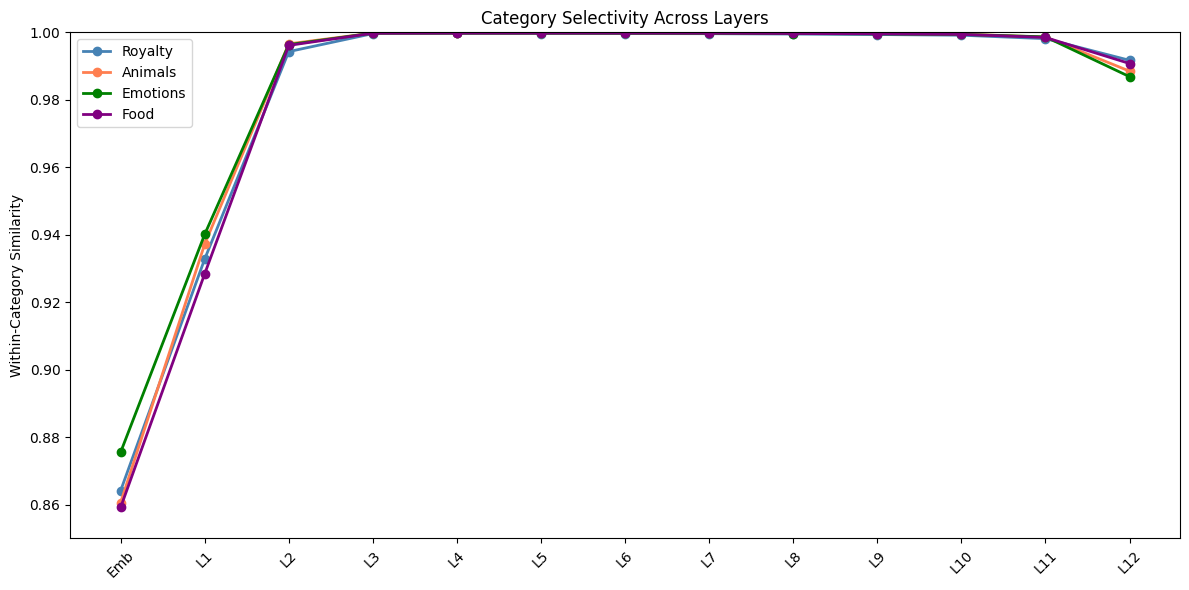

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ["steelblue", "coral", "green", "purple"]
x = range(n_layers)
xlabels = ["Emb"] + [f"L{i}" for i in range(1, 13)]

for (category, sims), color in zip(category_similarities.items(), colors):
    ax.plot(x, sims, marker='o', 
            label=category, color=color, linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=45)
ax.set_ylabel("Within-Category Similarity")
ax.set_title("Category Selectivity Across Layers")
ax.legend()
ax.set_ylim(0.85, 1.0)

plt.tight_layout()
plt.show()

* In the **middle layers**, all categories become almost similar.
* In the **early layers**, categories remain distinct from each other.
* In the **last layer**, some differentiation appears again.
* GPT-2 performs more **generalized processing in the middle layers**.
